In [ ]:
%cd /Users/csea/Desktop/projects/amazon-project
from src.data_preprocessing import preprocess
import pyspark
from pyspark.sql import functions as F
import re
import utils

spark = pyspark.sql.SparkSession.builder \
    .appName("Amazon Product Simplifier") \
    .getOrCreate()

# gets rid of the COLUMN ALREADY EXISTS error
spark.conf.set('spark.sql.caseSensitive', True) 
spark.catalog.clearCache()


REVIEW_DATA = 'dataset/sample/Clothing_Shoes_and_Jewelry.json'
PRODUCT_DATA = 'dataset/sample/meta_Clothing_Shoes_and_Jewelry.json'

/opt/miniconda3/envs/amazon/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/csea/Desktop/projects/amazon-project


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/12 16:52:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
reviews = spark.read.json(REVIEW_DATA)
products = preprocess(PRODUCT_DATA,spark)
# reviews.columns

In [3]:
products.createOrReplaceTempView("product_metadata")

In [48]:
products = products.withColumn('brand',
                            F.when(F.col('brand')=='unknown',None)
                            .otherwise(F.col('brand')))

In [49]:
# find all the brands 
QUERY = '''select brand,
                    count(*) as count
            from product_metadata
            group by brand
            order by count(*) DESC'''

spark.sql(QUERY).show()

+-----------------+-----+
|            brand|count|
+-----------------+-----+
|             null|  759|
|amazon collection|   34|
|            coach|   15|
|        shop4ever|    8|
|   the north face|    8|
|             jotw|    8|
|          unknown|    7|
|     michael kors|    7|
|      ellen tracy|    7|
|        old glory|    6|
|      acefast inc|    6|
|      hello kitty|    6|
|            gucci|    6|
|  forum novelties|    5|
|           geneva|    5|
|             vans|    5|
|            timex|    5|
|            casio|    4|
|          mud pie|    4|
|         themogan|    4|
+-----------------+-----+
only showing top 20 rows



We note that most of the brands in this sample are `NULL`.
This could be an error during data collection. We want to observe the titles of these products to see if they truly are unbranded or 'generic'




In [51]:
type(products)

pyspark.sql.dataframe.DataFrame

In [ ]:
# find all the title that is null
QUERY = '''select title, asin,brand
            from product_metadata
            where brand is null or brand='unknown'
            '''

spark.sql(QUERY).show(5,truncate=False)

+------------------------------------------------------------------------------------------------+----------+-------+
|title                                                                                           |asin      |brand  |
+------------------------------------------------------------------------------------------------+----------+-------+
|14k white gold triquetra celtic trinity pendant                                                 |B00DP6O7V4|unknown|
|sterling silver love hearts bead charm with fuchsia created ruby                                |B005BSOT8K|unknown|
|costumes for all occasions dg50235l spidergirl classic sm 4-6x                                  |B009BRIEOM|unknown|
|925 sterling silver mezuzah necklace for men with star of david pendant and enclosed scroll, 20"|B00MBF6DRG|unknown|
|stainless steel "i love you daughter" heart charm bead 158                                      |B01BNXIFAO|unknown|
+-------------------------------------------------------

In [6]:
# find all the brands not null
QUERY = '''select title, asin,brand
            from product_metadata
            where brand is not null or brand!='unknown'
            '''

spark.sql(QUERY).show(5,truncate=False)

+-------------------------------------------------------------------------------------------------------------------------+----------+------------------------+
|title                                                                                                                    |asin      |brand                   |
+-------------------------------------------------------------------------------------------------------------------------+----------+------------------------+
|guess shoes galone - black suede                                                                                         |B00591BB9O|guess                   |
|ellie shoes mens 129-clint western boot,                                                                                 |B00CM1M17A|ellie shoes             |
|pro jewelry .925 sterling silver " hot pink fuschia cz pavé heart sterling silver charm " for snake chain charm bracelets|B00DT4WMMS|pjewelry                |
|carlos by carlos santana womens maiko w

Though some are truly generic and unbranded, we see that there are some brands that are in the name.
Perhaps we can check if any words in the title are found in the brand?

In [7]:
brands = [brand[0] for brand in products.select('brand').distinct().collect() if brand[0] is not None]
regex_pattern = r"(?i)\b(" + "|".join(brands) + r")\b"  


products.withColumn('matched_keyword',
                    F.regexp_extract(F.col('title'), regex_pattern,0))\
            .filter(F.col('matched_keyword')!='')\
            .filter(F.col('brand').isNull())\
            .select(['brand','title','matched_keyword'])\
            .show(5,truncate=False)

+-----+--------------------------------------------------------------------------------------------------+---------------+
|brand|title                                                                                             |matched_keyword|
+-----+--------------------------------------------------------------------------------------------------+---------------+
|null |halter style o ring cut out design one piece monokini bikini summer swimwear (medium ombre orange)|ring           |
|null |disney the muppets kermit costume                                                                 |disney         |
|null |nike air max tailwind 7 men round toe synthetic black running shoe                                |nike           |
|null |go all out screenprinting adult this is how i roll 20 sided die t-shirt                           |go all out     |
|null |under armour little boys branded short sleeve tee                                                 |under armour   |
+-----+---------

In [8]:
# matching brand found in title count
match_count = products.withColumn('matched_keyword',
                    F.regexp_extract(F.col('title'), regex_pattern,0))\
            .filter(F.col('matched_keyword')!='')\
            .filter(F.col('brand').isNull())\
            .select(['brand','title','matched_keyword'])\
            .count()
# nothing found in tile
no_match_count = products.withColumn('matched_keyword',
                    F.regexp_extract(F.col('title'), regex_pattern,0))\
            .filter(F.col('matched_keyword')=='')\
            .filter(F.col('brand').isNull())\
            .count()


print(f'{match_count} titles matched existing brand data')
print(f'{no_match_count} titles has no match')

174 titles matched existing brand data
585 titles has no match


seems like you can auto capture brand name because it follwos the followig convention

`[brand name] [women/ men/ girls/ boys] ... `

we will collect the words after the brand and try to 'reverse-match' for the products without a brand.


We can also use the category to our advantage

In [9]:
# capture the word after the brand to see if we can manually 
# extract the brand through the key word 
regex_pattern = r"\b(" + "|".join([re.escape(b) for b in brands]) + r")\b\s+(\w+)"
products.withColumn('matched_keyword',
                    F.regexp_extract(F.col('title'), regex_pattern,1))\
        .withColumn('next_word',
                    F.regexp_extract(F.col('title'), regex_pattern,2))\
            .filter(F.col('matched_keyword')!='')\
            .filter(F.col('brand').isNotNull())\
            .select(['brand','title','matched_keyword','next_word'])\
            .show(5,truncate=False)


+------------------------+--------------------------------------------------+------------------------+---------+
|brand                   |title                                             |matched_keyword         |next_word|
+------------------------+--------------------------------------------------+------------------------+---------+
|guess                   |guess shoes galone - black suede                  |guess                   |shoes    |
|ellie shoes             |ellie shoes mens 129-clint western boot,          |ellie shoes             |mens     |
|carlos by carlos santana|carlos by carlos santana womens maiko wedge sandal|carlos by carlos santana|womens   |
|sedagatti               |sedagatti mens luxury casual slip on boat shoes   |sedagatti               |mens     |
|cha cha vente           |cha cha vente womens slub rib tank                |cha cha vente           |womens   |
+------------------------+--------------------------------------------------+-------------------

In [10]:
next_words = products.withColumn('next_word',
                    F.regexp_extract(F.col('title'), regex_pattern,2))\
                    .select('next_word')\
                    .distinct().collect()
next_words = [word[0] for word in next_words if word[0]!="" and  word[0].isdigit()==False]

In [11]:
next_word = products.withColumn('next_word',
                    F.regexp_extract(F.col('title'), regex_pattern,2))\
                    .select('next_word')
                    # .select(['next_word','category'])


next_word.createOrReplaceTempView("word")
QUERY = '''
            select next_word, count(next_word) as count
            from word
            group by next_word
            having next_word<>""
            order by count desc
        '''
# spark.sql(QUERY).show(truncate=False)
count = spark.sql(QUERY)
count.show(5)


+---------+-----+
|next_word|count|
+---------+-----+
|   womens|  310|
|     mens|  207|
|     baby|   28|
|   little|   23|
|    women|   20|
+---------+-----+
only showing top 5 rows



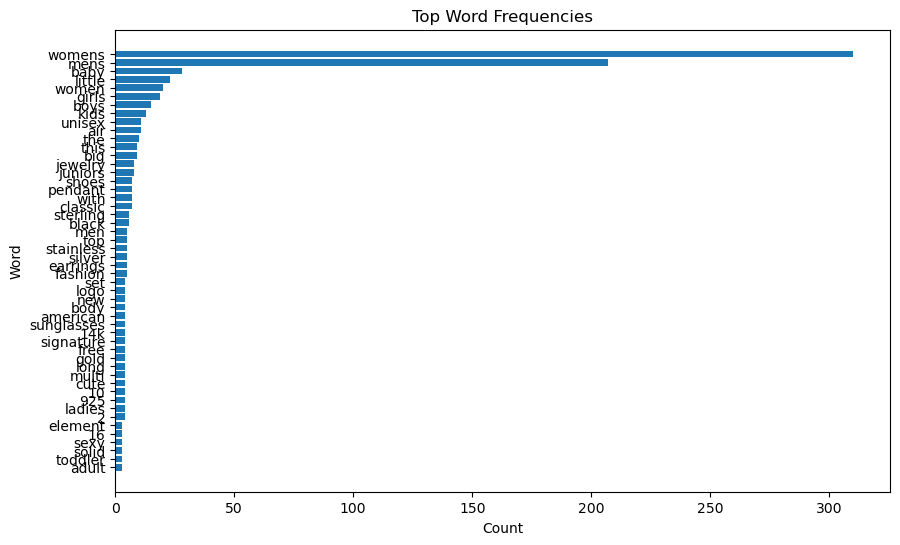

In [12]:
import matplotlib.pyplot as plt

local_data = count.orderBy('count', ascending=False).collect()

words = [row['next_word'] for row in local_data[:50]]
counts = [row['count'] for row in local_data[:50]]

plt.figure(figsize=(10, 6))
plt.barh(words, counts)
plt.title('Top Word Frequencies')
plt.xlabel('Count')
plt.ylabel('Word')
plt.gca().invert_yaxis()  # Highest count at top
plt.show()

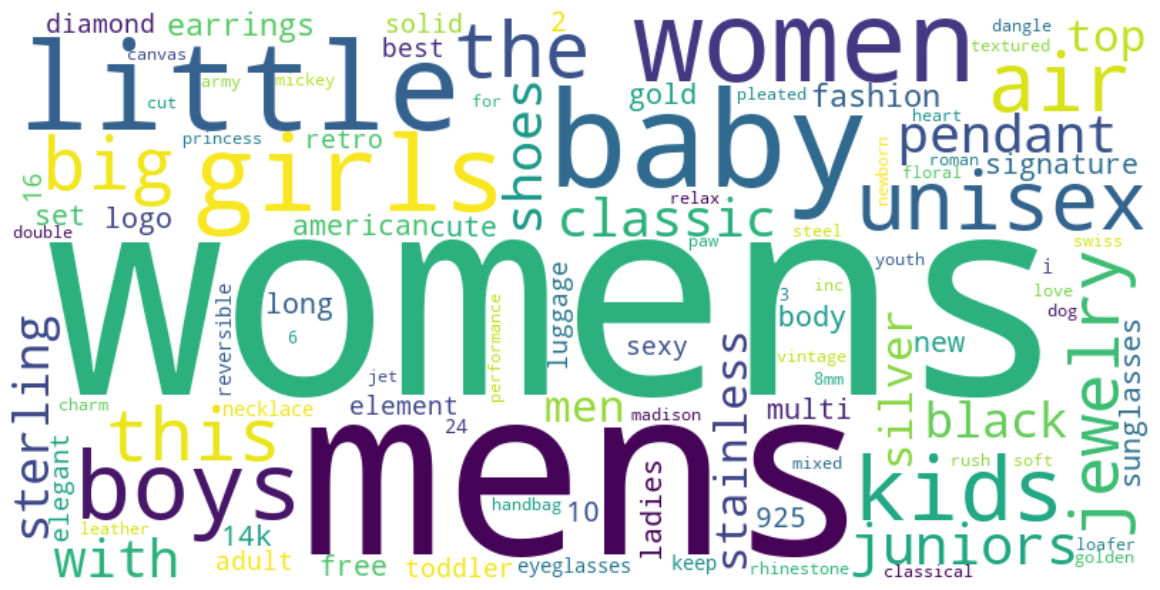

In [13]:
from wordcloud import WordCloud

# Create frequency dictionary
word_freq = dict(count.orderBy("count", ascending=False).limit(100)
                      .rdd.map(lambda row: (row['next_word'], row['count']))
                      .collect())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, 
                     background_color='white').generate_from_frequencies(word_freq)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

using manual inspection - we see that from the top 100 words, gender and age specific description follows the brand names. We will use this to try to extract the brands that we still have yet to extract from the brand list.

In [14]:
key_words = ['womens','women','mens','men','little','boys','girls','baby','unisex','adult','juniors','ladies']

# regex match the any of the brands AND any of the keywords

In [15]:
# capture the word after the brand to see if we can manually 
# extract the brand through the key word 
regex_pattern = r"^(.*?)\ "+r"\b(" + "|".join([re.escape(b) for b in key_words]) + r")\b"
products.withColumn('matched_keyword',
                    F.regexp_extract(F.col('title'), regex_pattern,2))\
        .withColumn('prev_word',
                    F.regexp_extract(F.col('title'), regex_pattern,1))\
            .filter(F.col('matched_keyword')!='')\
            .filter(F.col('brand').isNull())\
            .select(['brand','title','matched_keyword','prev_word'])\
            .show(10,truncate=False)


+-----+--------------------------------------------------------------------------------------+---------------+-------------------------+
|brand|title                                                                                 |matched_keyword|prev_word                |
+-----+--------------------------------------------------------------------------------------+---------------+-------------------------+
|null |privo womens lennie boot                                                              |womens         |privo                    |
|null |papi mens 3-pack cotton thong                                                         |mens           |papi                     |
|null |tommy hilfiger boys short sleeve ivy polo shirt                                       |boys           |tommy hilfiger           |
|null |billabong mens essential tie dye tank                                                 |mens           |billabong                |
|null |nike air max tailwind 7 men round 

we kinda have a formula to extract now
1. get the brand from the brand list 
2. if no brand, grab the word from the key list and try that 

In [16]:
brand_pattern = r"\b(" + "|".join([re.escape(b) for b in brands]) + r")\b"
keyword_pattern = r"^(.*?)\ "+r"\b(" + "|".join([re.escape(b) for b in key_words]) + r")\b"

brand_results = products.withColumn(
                "brand_match",
                F.when(
                    F.col('title').rlike(brand_pattern),
                    F.regexp_extract('title',brand_pattern,0).alias('match'),
                )
            ).withColumn(
                'keyword_match',
                F.when(
                    (F.col('brand_match').isNull()) &
                    (F.col('title').rlike(keyword_pattern)),
                    F.regexp_extract('title',keyword_pattern,1).alias('match'),
                )
            ).withColumn(
                "final_result",
                F.coalesce(F.col('brand'),F.col("brand_match"), F.col("keyword_match"))
            )

In [17]:
brand_results.select(['title','brand','brand_match','keyword_match','final_result']) \
            .filter(F.col('brand').isNull())\
            .show(3,truncate=0)

+-----------------------------------------------+-----+-----------+--------------+--------------+
|title                                          |brand|brand_match|keyword_match |final_result  |
+-----------------------------------------------+-----+-----------+--------------+--------------+
|privo womens lennie boot                       |null |null       |privo         |privo         |
|papi mens 3-pack cotton thong                  |null |null       |papi          |papi          |
|tommy hilfiger boys short sleeve ivy polo shirt|null |null       |tommy hilfiger|tommy hilfiger|
+-----------------------------------------------+-----+-----------+--------------+--------------+
only showing top 3 rows



In [18]:
brand_results.select('final_result')\
                .groupBy('final_result')\
               .agg(F.count("*").alias("match_count"))\
               .orderBy(F.desc("match_count"))\
               .show(10)

+-----------------+-----------+
|     final_result|match_count|
+-----------------+-----------+
|             null|        123|
|             nike|         45|
|amazon collection|         34|
|     under armour|         16|
|            coach|         15|
|           disney|         15|
|     calvin klein|         14|
|   the north face|          9|
|             ring|          9|
|           adidas|          9|
+-----------------+-----------+
only showing top 10 rows



In [19]:
empty_count = brand_results.filter(F.col('final_result').isNull()).count()
print(f'Still {empty_count} titles with no brand')

Still 123 titles with no brand


need to collect the final results brand and run one mroe time in case we missed a non keyword item

In [20]:
brands_2 = [b[0] for b in brand_results.select('final_result').collect() if b[0] is not None]
brands_2 = [b for b in brands_2 if b!='']

In [ ]:
regex_pattern = r"\b(" + "|".join([re.escape(b) for b in brands_2]) + r")\b"

# brand_results.withColumn('matched',
#                     F.regexp_extract(F.col('title'), regex_pattern,0))\
#             .filter(F.col('matched')!='')\
#             .filter(F.col('brand').isNull())\
#             .filter(F.col('final_result')=="")\
#             .select(['brand','title','matched','final_result'])\
#             .show()

brand_results = brand_results.withColumn('matched',
                                F.regexp_extract(F.col('title'), regex_pattern,0))\
                        .withColumn('final_result',F.coalesce(F.col('final_result'),F.col('matched')))


In [23]:
brand_results.select(['title','matched','brand_match','keyword_match','final_result']) \
            .filter(F.col('brand').isNull())\
            .filter(F.col('keyword_match').isNull())\
            .show(5,truncate=0)

+--------------------------------------------------------------------------------------------------+-------+-----------+-------------+------------+
|title                                                                                             |matched|brand_match|keyword_match|final_result|
+--------------------------------------------------------------------------------------------------+-------+-----------+-------------+------------+
|womens long beach designer dress swimwear swimsuit kimono cover up kaftan maxi                    |       |null       |null         |            |
|womens plus size metallic leggings black metallic,3x                                              |       |null       |null         |            |
|halter style o ring cut out design one piece monokini bikini summer swimwear (medium ombre orange)|ring   |ring       |null         |ring        |
|disney the muppets kermit costume                                                                 |disney |disn

In [24]:
brand_results.select('final_result')\
                .groupBy('final_result')\
               .agg(F.count("*").alias("match_count"))\
               .orderBy(F.desc("match_count"))\
               .show(10)

+-----------------+-----------+
|     final_result|match_count|
+-----------------+-----------+
|                 |         88|
|             nike|         45|
|amazon collection|         34|
|     under armour|         16|
|           disney|         15|
|            coach|         15|
|     calvin klein|         14|
|           fossil|         11|
|   the north face|          9|
|             ring|          9|
+-----------------+-----------+
only showing top 10 rows



In [42]:
brand_results.select(['title','final_result'])\
                .filter(F.col('final_result')=='unknown').show(5,truncate=False)

+------------------------------------------------------------------------------------------------+------------+
|title                                                                                           |final_result|
+------------------------------------------------------------------------------------------------+------------+
|14k white gold triquetra celtic trinity pendant                                                 |unknown     |
|sterling silver love hearts bead charm with fuchsia created ruby                                |unknown     |
|costumes for all occasions dg50235l spidergirl classic sm 4-6x                                  |unknown     |
|925 sterling silver mezuzah necklace for men with star of david pendant and enclosed scroll, 20"|unknown     |
|stainless steel "i love you daughter" heart charm bead 158                                      |unknown     |
+------------------------------------------------------------------------------------------------+------

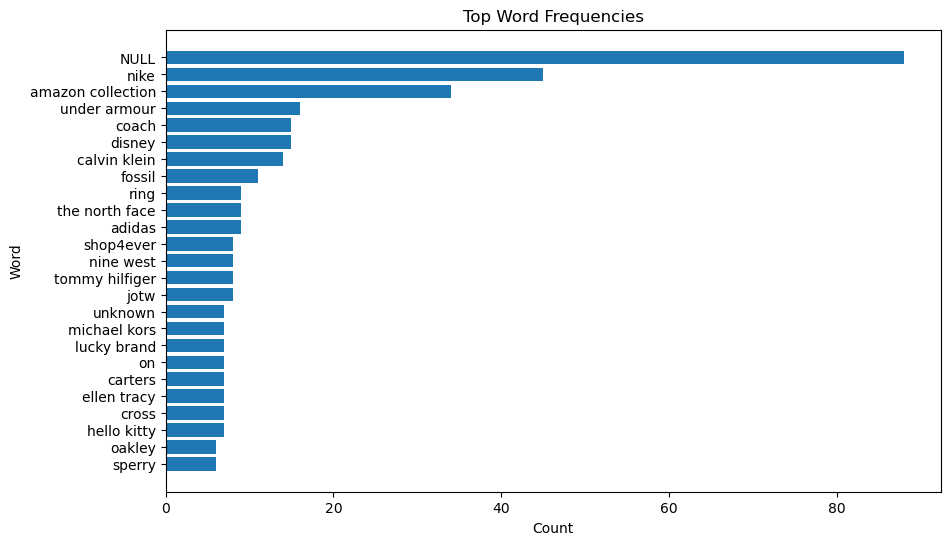

In [35]:
local_brand = brand_results.select('final_result')\
                .groupBy('final_result')\
               .agg(F.count("*").alias("match_count"))\
               .orderBy(F.desc("match_count")).collect()


words = [row['final_result'] for row in local_brand[:25]]
counts = [row['match_count'] for row in local_brand[:25]]
words[0] = 'NULL'

plt.figure(figsize=(10, 6))
plt.barh(words, counts)
plt.title('Top Word Frequencies')
plt.xlabel('Count')
plt.ylabel('Word')
plt.gca().invert_yaxis()  # Highest count at top
plt.show()
               

In [64]:
spark.stop()
